In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [3]:
df = pd.read_csv("C:/Users/DELL/OneDrive/Desktop/Semester 1/Projects/Customer_Churn/Data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.shape

(7043, 21)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [9]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [10]:
df["Churn"].value_counts(normalize=True)

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [11]:
pd.crosstab(df["Contract"], df["Churn"], normalize="index")

Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


In [12]:
pd.crosstab(df["gender"], df["Churn"], normalize="index")

Churn,No,Yes
gender,,
Female,0.730791,0.269209
Male,0.738397,0.261603


In [13]:
pd.crosstab(df["SeniorCitizen"], df["Churn"], normalize="index")

Churn,No,Yes
SeniorCitizen,,
0,0.763938,0.236062
1,0.583187,0.416813


In [14]:
pd.crosstab(df["Dependents"], df["Churn"], normalize="index")

Churn,No,Yes
Dependents,,
No,0.687209,0.312791
Yes,0.845498,0.154502


In [15]:
pd.crosstab(df["Partner"], df["Churn"], normalize="index")

Churn,No,Yes
Partner,,
No,0.670420,0.329580
Yes,0.803351,0.196649


In [16]:
pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index")

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),0.832902,0.167098
Credit card (automatic),0.847569,0.152431
Electronic check,0.547146,0.452854
Mailed check,0.808933,0.191067


In [17]:
df["TotalCharges"].dtype

<StringDtype(storage='python', na_value=nan)>

In [18]:
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[0, 12, 24, 48, 72],
    labels=[
        "0-12 months",
        "13-24 months",
        "25-48 months",
        "49-72 months"
    ]
)

In [19]:
pd.crosstab(df["tenure_group"], df["Churn"], normalize="index")


Churn,No,Yes
tenure_group,,
0-12 months,0.523218,0.476782
13-24 months,0.712891,0.287109
25-48 months,0.796110,0.203890
49-72 months,0.904868,0.095132


In [20]:
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"],
    errors="coerce"
)

In [21]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [22]:
df["TotalCharges"]=df["TotalCharges"].fillna(0)

In [23]:
df["TotalCharges"].isnull().sum()

np.int64(0)

In [24]:
df=df.drop("customerID",axis=1)

In [25]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

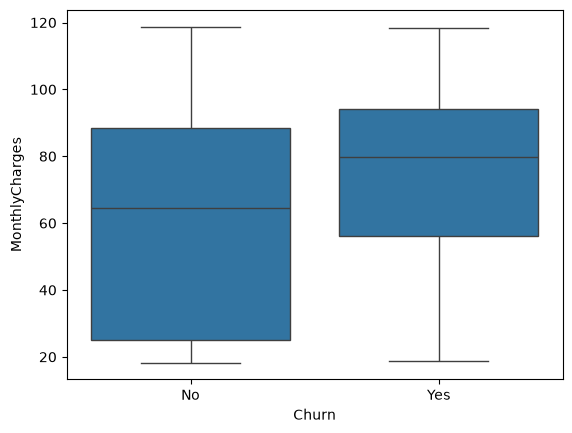

In [26]:
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")

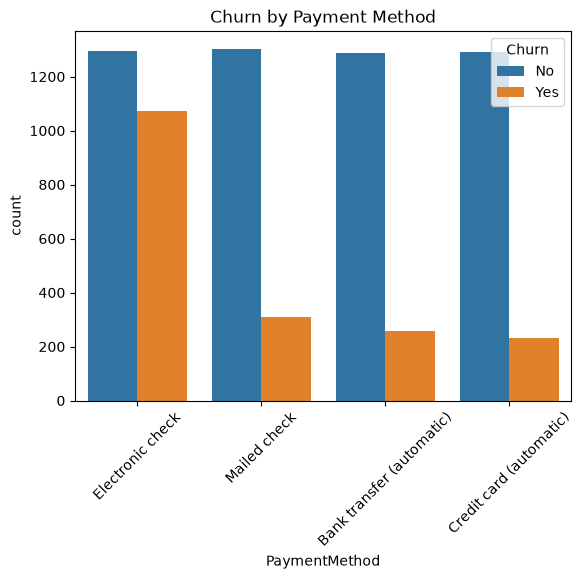

In [27]:
sns.countplot(
    data=df,
    x="PaymentMethod",
    hue="Churn"
)

plt.xticks(rotation=45)
plt.title("Churn by Payment Method")
plt.show()

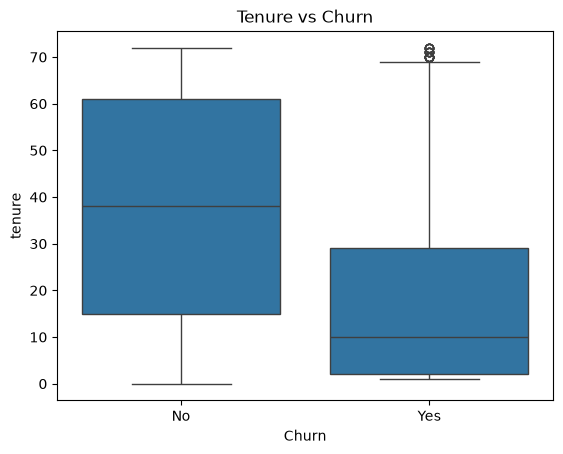

In [28]:
sns.boxplot(
    data=df,
    x="Churn",
    y="tenure"
)

plt.title("Tenure vs Churn")
plt.show()

In [29]:
X=df.drop("Churn",axis=1)
Y=df["Churn"]

In [30]:
Y = Y.map({
    "Yes": 1,
    "No": 0
})

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

In [32]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

baseline_model = DummyClassifier(strategy="most_frequent")

baseline_model.fit(X_train, Y_train)

baseline_preds = baseline_model.predict(X_test)

baseline_accuracy = accuracy_score(Y_test, baseline_preds)
print(f"Baseline (Majority Class) Accuracy: {baseline_accuracy:.4f}")


Baseline (Majority Class) Accuracy: 0.7346


In [33]:
numerical_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

categorical_features=[
    col for col in X_train.columns
    if col not in numerical_features
]

In [34]:
print(categorical_features)

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group']


In [35]:
print(numerical_features)

['tenure', 'MonthlyCharges', 'TotalCharges']


In [36]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [37]:
preprocessor= ColumnTransformer(
    transformers=[
        ("numbers",StandardScaler(),numerical_features),
        ("cat",OneHotEncoder(handle_unknown="ignore"),categorical_features)
        
    ]
)

In [38]:
for tranformer in preprocessor.transformers:
    print(tranformer)

('numbers', StandardScaler(), ['tenure', 'MonthlyCharges', 'TotalCharges'])
('cat', OneHotEncoder(handle_unknown='ignore'), ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group'])


In [39]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [40]:
LogisticRegression_model = Pipeline(
    steps=[
        ("preprocessor",preprocessor),
        ("Logistic_Regression",LogisticRegression(max_iter=1000))
    ]
)

In [41]:
LogisticRegression_model.fit(X_train,Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('Logistic_Regression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['gender','SeniorCitizen','Partner',...,'MonthlyCharges','TotalCharges', 'tenure_group']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numbers', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifyin

In [42]:
Y_pred= LogisticRegression_model.predict(X_test)

In [43]:
print(Y_pred[:20])

[0 1 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0]


In [44]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

In [45]:
print(
    "Accuracy:",
    accuracy_score(Y_test, Y_pred)
)

Accuracy: 0.7991483321504613


In [46]:
print(
    "Precision:",
    precision_score(Y_test, Y_pred)
)

Precision: 0.6531986531986532


In [47]:
print(
    "f1 Score:",
    f1_score(Y_test, Y_pred)
)

f1 Score: 0.5782414307004471


In [48]:
print(
    "Recall Score:",
    recall_score(Y_test, Y_pred)
)

Recall Score: 0.5187165775401069


In [49]:
print(
    "ROC AUC Score:",
    roc_auc_score(Y_test, Y_pred)
)

ROC AUC Score: 0.7095998346637732


In [50]:
Y_prob = LogisticRegression_model.predict_proba(X_test)[:, 1]

In [51]:
print(
    "ROC AUC Score:",
    roc_auc_score(Y_test, Y_prob)
)

ROC AUC Score: 0.8423570745821385


In [52]:
print(
    classification_report(Y_test,Y_pred)
)

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



In [53]:
from sklearn.metrics import confusion_matrix

In [54]:
Conf_Matrix= confusion_matrix(
    Y_test,Y_pred
)

Text(50.83333333333333, 0.5, 'Actual')

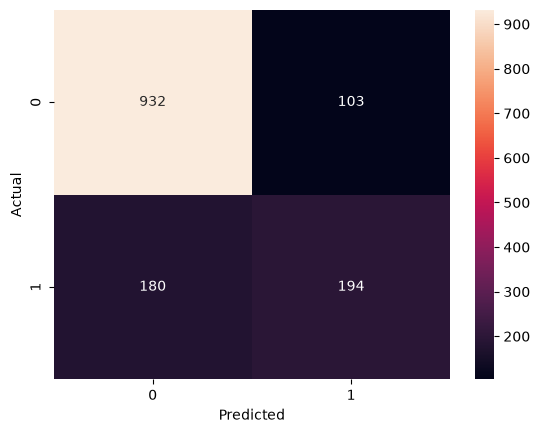

In [55]:
sns.heatmap(
    Conf_Matrix,
    annot=True,
    fmt="d"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")

In [56]:
print(Conf_Matrix)

[[932 103]
 [180 194]]


In [57]:
print("Accuracy:", accuracy_score(Y_test, Y_pred))
print("Precision:", precision_score(Y_test, Y_pred))
print("Recall:", recall_score(Y_test, Y_pred))
print("F1:", f1_score(Y_test, Y_pred))

Accuracy: 0.7991483321504613
Precision: 0.6531986531986532
Recall: 0.5187165775401069
F1: 0.5782414307004471


In [58]:

print(
    "ROC-AUC:",
    roc_auc_score(Y_test, Y_prob)
)

ROC-AUC: 0.8423570745821385


In [59]:
for threshold in [0.3,0.35,0.38, 0.4, 0.5, 0.6, 0.7]:

    Y_pred_threshold = (Y_prob >= threshold).astype(int)

    precision = precision_score(Y_test, Y_pred_threshold)
    recall = recall_score(Y_test, Y_pred_threshold)
    f1 = f1_score(Y_test, Y_pred_threshold)

    print(
        f"Threshold: {threshold}"
        f" | Precision: {precision:.3f}"
        f" | Recall: {recall:.3f}"
        f" | F1: {f1:.3f}"
    )

Threshold: 0.3 | Precision: 0.524 | Recall: 0.757 | F1: 0.619
Threshold: 0.35 | Precision: 0.560 | Recall: 0.714 | F1: 0.627
Threshold: 0.38 | Precision: 0.568 | Recall: 0.679 | F1: 0.619
Threshold: 0.4 | Precision: 0.582 | Recall: 0.658 | F1: 0.617
Threshold: 0.5 | Precision: 0.653 | Recall: 0.519 | F1: 0.578
Threshold: 0.6 | Precision: 0.709 | Recall: 0.377 | F1: 0.492
Threshold: 0.7 | Precision: 0.743 | Recall: 0.225 | F1: 0.345


In [60]:
threshold=0.35
Y_pred_threshold = (Y_prob >= threshold).astype(int)

In [61]:
print("Accuracy:", accuracy_score(Y_test, Y_pred_threshold))
print("Precision:", precision_score(Y_test, Y_pred_threshold))
print("Recall:", recall_score(Y_test, Y_pred_threshold))
print("F1:", f1_score(Y_test, Y_pred_threshold))

Accuracy: 0.7750177430801988
Precision: 0.559748427672956
Recall: 0.713903743315508
F1: 0.627497062279671


In [62]:
Conf_Matrix2 = confusion_matrix(
    Y_test,
    Y_pred_threshold
)

Text(0.5, 1.0, 'Confusion Matrix')

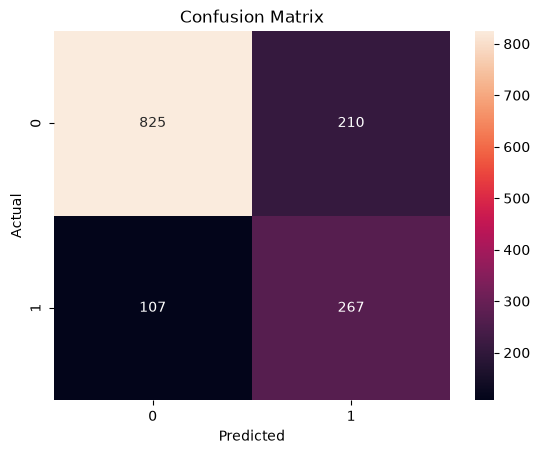

In [63]:
sns.heatmap(
    Conf_Matrix2,
    annot=True,
    fmt='d'
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

In [64]:
print(Conf_Matrix2)

[[825 210]
 [107 267]]


In [65]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

In [66]:
rf_model = Pipeline(
    steps=[
        ("preprocessor",preprocessor),
        ("RandF_Classifier",RandomForestClassifier(n_estimators=200,random_state=42))
    ]
)

In [67]:
rf_model.fit(X_train,Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('RandF_Classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['gender','SeniorCitizen','Partner',...,'MonthlyCharges','TotalCharges', 'tenure_group']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numbers', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying `

In [68]:
Y_pred_rf= rf_model.predict(X_test)

In [69]:
Y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [70]:
Y_prob_rf[:20]

array([0.   , 0.765, 0.05 , 0.235, 0.005, 0.38 , 0.415, 0.095, 0.005,
       0.43 , 0.19 , 0.   , 0.215, 0.65 , 0.1  , 0.095, 0.05 , 0.69 ,
       0.135, 0.045])

In [71]:
print("Accuracy Score:",accuracy_score(Y_test,Y_pred_rf))
print("Precision Score:",precision_score(Y_test,Y_pred_rf))
print("Recall Score:",recall_score(Y_test,Y_pred_rf))
print("F1 Score:",f1_score(Y_test,Y_pred_rf))

Accuracy Score: 0.7849538679914834
Precision Score: 0.6187290969899666
Recall Score: 0.4946524064171123
F1 Score: 0.549777117384844


In [72]:
print("ROC-AUC:", roc_auc_score(Y_test, Y_prob_rf))

ROC-AUC: 0.8236172466351495


In [73]:
print(Y_prob_rf.min())
print(Y_prob_rf.max())

0.0
1.0


In [74]:
print(len(Y_test))
print(len(Y_prob_rf))

1409
1409


In [75]:
from sklearn.metrics import precision_score, recall_score, f1_score
results=[]
for threshold in [0.33, 0.35,0.36, 0.38, 0.39, 0.4, 0.45]:
    pred = (Y_prob_rf >= threshold).astype(int)

    precision = precision_score(Y_test, pred)
    recall = recall_score(Y_test, pred)
    f1 = f1_score(Y_test, pred)

    results.append([threshold,precision,recall,f1])
    
    print(
        f"Threshold: {threshold}"
        f" | Precision: {precision:.3f}"
        f" | Recall: {recall:.3f}"
        f" | F1: {f1:.3f}"
    )

Threshold: 0.33 | Precision: 0.516 | Recall: 0.690 | F1: 0.590
Threshold: 0.35 | Precision: 0.541 | Recall: 0.676 | F1: 0.601
Threshold: 0.36 | Precision: 0.546 | Recall: 0.668 | F1: 0.601
Threshold: 0.38 | Precision: 0.558 | Recall: 0.642 | F1: 0.597
Threshold: 0.39 | Precision: 0.561 | Recall: 0.636 | F1: 0.596
Threshold: 0.4 | Precision: 0.570 | Recall: 0.623 | F1: 0.595
Threshold: 0.45 | Precision: 0.587 | Recall: 0.548 | F1: 0.567


In [76]:
results_df = pd.DataFrame(
    results,
    columns=["Threshold","Precision","Recall","F1"]
)
print(results_df)

   Threshold  Precision    Recall        F1
0       0.33   0.516000  0.689840  0.590389
1       0.35   0.540598  0.676471  0.600950
2       0.36   0.545852  0.668449  0.600962
3       0.38   0.558140  0.641711  0.597015
4       0.39   0.561321  0.636364  0.596491
5       0.40   0.569682  0.622995  0.595147
6       0.45   0.587393  0.548128  0.567082


In [77]:
best_row= results_df.loc[results_df["F1"].idxmax()]
print(best_row)

Threshold    0.360000
Precision    0.545852
Recall       0.668449
F1           0.600962
Name: 2, dtype: float64


In [78]:
# best_threshold = best_row["Threshold"]
# best_f1 = best_row["F1"]
# best_precision = best_row["Precision"]
# best_recall = best_row["Recall"]

print("Best Threshold:", best_row["Threshold"])
print("Precision:", best_row["Precision"])
print("Recall:", best_row["Recall"])
print("F1:", best_row["F1"])

Best Threshold: 0.36
Precision: 0.5458515283842795
Recall: 0.6684491978609626
F1: 0.6009615384615384


In [79]:
Y_pred_rf_best_th= (Y_prob >= best_row["Threshold"]).astype(int)

In [80]:
print("Accuracy Score:",accuracy_score(Y_test,Y_pred_rf_best_th))
print("Precision Score:",precision_score(Y_test,Y_pred_rf_best_th))
print("Recall Score:",recall_score(Y_test,Y_pred_rf_best_th))
print("F1 Score:",f1_score(Y_test,Y_pred_rf_best_th))

Accuracy Score: 0.7750177430801988
Precision Score: 0.5607675906183369
Recall Score: 0.7032085561497327
F1 Score: 0.6239620403321471


In [81]:
roc_auc = roc_auc_score(Y_test, Y_prob_rf)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8236172466351495


In [82]:
Conf_Matrix_rf = confusion_matrix(
    Y_test,
    Y_pred_rf_best_th
)

In [83]:
Conf_Matrix_rf

array([[829, 206],
       [111, 263]])

In [84]:
print(
    classification_report(Y_test,Y_pred_rf_best_th)
)

              precision    recall  f1-score   support

           0       0.88      0.80      0.84      1035
           1       0.56      0.70      0.62       374

    accuracy                           0.78      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.80      0.78      0.78      1409



In [85]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

In [86]:
cv= StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [87]:
params_grid = {
    "RandF_Classifier__n_estimators":[100,200],
    "RandF_Classifier__max_depth": [5, 10, None],
    "RandF_Classifier__min_samples_split": [2, 5],
    "RandF_Classifier__min_samples_leaf": [1, 2]
}

In [91]:
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=params_grid,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

In [92]:
grid_search.fit(X_train,Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'RandF_Classifier__max_depth': [5, 10, ...], 'RandF_Classifier__min_samples_leaf': [1, 2], 'RandF_Classifier__min_samples_split': [2, 5], 'RandF_Classifier__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and

In [94]:
print(grid_search.best_params_)
print(grid_search.best_score_)

{'RandF_Classifier__max_depth': 10, 'RandF_Classifier__min_samples_leaf': 1, 'RandF_Classifier__min_samples_split': 5, 'RandF_Classifier__n_estimators': 200}
0.5808694984115932


In [96]:
best_vali_rf= grid_search.best_estimator_

Y_pred_tuned= best_vali_rf.predict(X_test)
Y_prob_tuned= best_vali_rf.predict_proba(X_test)[:,1]

In [98]:
print("Accuracy",accuracy_score(Y_test,Y_pred_tuned))
print("Recall",recall_score(Y_test,Y_pred_tuned))
print("Precision",precision_score(Y_test,Y_pred_tuned))
print("F1",f1_score(Y_test,Y_pred_tuned))
print("ROC-AUC",roc_auc_score(Y_test,Y_prob_tuned))

Accuracy 0.7984386089425124
Recall 0.5026737967914439
Precision 0.6573426573426573
F1 0.5696969696969697
ROC-AUC 0.8392221447208659


In [99]:
for threshold in [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]:

    Y_pred_threshold = (Y_prob_tuned >= threshold).astype(int)

    precision = precision_score(Y_test, Y_pred_threshold)
    recall = recall_score(Y_test, Y_pred_threshold)
    f1 = f1_score(Y_test, Y_pred_threshold)

    print(
        f"Threshold: {threshold:.2f}"
        f" | Precision: {precision:.3f}"
        f" | Recall: {recall:.3f}"
        f" | F1: {f1:.3f}"
    )

Threshold: 0.20 | Precision: 0.460 | Recall: 0.856 | F1: 0.599
Threshold: 0.25 | Precision: 0.493 | Recall: 0.807 | F1: 0.612
Threshold: 0.30 | Precision: 0.534 | Recall: 0.765 | F1: 0.629
Threshold: 0.35 | Precision: 0.556 | Recall: 0.725 | F1: 0.630
Threshold: 0.40 | Precision: 0.576 | Recall: 0.650 | F1: 0.611
Threshold: 0.45 | Precision: 0.616 | Recall: 0.591 | F1: 0.603
Threshold: 0.50 | Precision: 0.657 | Recall: 0.503 | F1: 0.570
Threshold: 0.55 | Precision: 0.683 | Recall: 0.420 | F1: 0.520
Threshold: 0.60 | Precision: 0.759 | Recall: 0.353 | F1: 0.482


In [102]:
threshold=0.35
Y_pred_threshold_rf_tuned = (Y_prob_tuned >= threshold).astype(int)
precision = precision_score(Y_test, Y_pred_threshold_rf_tuned)
recall = recall_score(Y_test, Y_pred_threshold_rf_tuned)
f1 = f1_score(Y_test, Y_pred_threshold_rf_tuned)

print(
    f"Threshold: {threshold:.2f}"
    f" | Precision: {precision:.3f}"
    f" | Recall: {recall:.3f}"
    f" | F1: {f1:.3f}"
)

Threshold: 0.35 | Precision: 0.556 | Recall: 0.725 | F1: 0.630


In [103]:
Conf_Matrix_tuned_rf = confusion_matrix(
    Y_test,
    Y_pred_threshold_rf_tuned
)

In [104]:
Conf_Matrix_tuned_rf

array([[819, 216],
       [103, 271]])

Text(0.5, 1.0, 'Confusion Matrix')

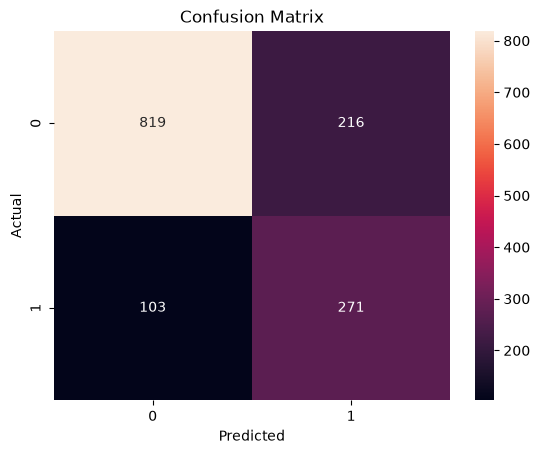

In [107]:
sns.heatmap(
    Conf_Matrix_tuned_rf,
    annot=True,
    fmt='d'
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")


In [110]:
print(classification_report(Y_test,Y_pred_threshold_rf_tuned))

              precision    recall  f1-score   support

           0       0.89      0.79      0.84      1035
           1       0.56      0.72      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409



In [115]:
false_negatives = X_test[
    (Y_test == 1) & (Y_pred_threshold_rf_tuned == 0)
]

# print(false_negatives.head())
print("Number of False Negatives:", len(false_negatives))

Number of False Negatives: 103


In [116]:
false_positives = X_test[
    (Y_test == 0) & (Y_pred_threshold_rf_tuned == 1)
]

# print(false_positives.head())
print("Number of False Positives:", len(false_positives))

Number of False Positives: 216


In [114]:
for col in ["Contract", "InternetService", "PaymentMethod", "tenure_group"]:
    print("\n---", col, "---")
    print(
        df.groupby(col)["Churn"]
        .apply(lambda x: (x == "Yes").mean())
    )


--- Contract ---
Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn, dtype: float64

--- InternetService ---
InternetService
DSL            0.189591
Fiber optic    0.418928
No             0.074050
Name: Churn, dtype: float64

--- PaymentMethod ---
PaymentMethod
Bank transfer (automatic)    0.167098
Credit card (automatic)      0.152431
Electronic check             0.452854
Mailed check                 0.191067
Name: Churn, dtype: float64

--- tenure_group ---
tenure_group
0-12 months     0.476782
13-24 months    0.287109
25-48 months    0.203890
49-72 months    0.095132
Name: Churn, dtype: float64


In [118]:
from xgboost import XGBClassifier

In [142]:
xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("XGB_Classifier", XGBClassifier(
            n_estimators=200,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            eval_metric="logloss"
        ))
    ]
)

In [143]:
xgb_model.fit(X_train,Y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('XGB_Classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](20,)","['gender','SeniorCitizen','Partner',...,'MonthlyCharges','TotalCharges', 'tenure_group']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,20
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numbers', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``r

In [145]:
Y_pred_xgb= xgb_model.predict(X_test)
Y_prob_xgb= xgb_model.predict_proba(X_test)[:,1]

In [146]:
print("Accuracy:", accuracy_score(Y_test, Y_pred_xgb))
print("Precision:", precision_score(Y_test, Y_pred_xgb))
print("Recall:", recall_score(Y_test, Y_pred_xgb))
print("F1:", f1_score(Y_test, Y_pred_xgb))
print("ROC-AUC:", roc_auc_score(Y_test, Y_prob_xgb))

Accuracy: 0.801277501774308
Precision: 0.6556291390728477
Recall: 0.5294117647058824
F1: 0.5857988165680473
ROC-AUC: 0.843629388514299


In [147]:
print("Accuracy------------Precision------------Recall-------------F1_Score")
for i in [Y_pred_threshold,Y_pred_threshold_rf_tuned,Y_pred_xgb]:
    print(accuracy_score(Y_test, i),precision_score(Y_test, i),recall_score(Y_test, i),f1_score(Y_test, i))

Accuracy------------Precision------------Recall-------------F1_Score
0.7735982966643009 0.5564681724845996 0.7245989304812834 0.629500580720093
0.7735982966643009 0.5564681724845996 0.7245989304812834 0.629500580720093
0.801277501774308 0.6556291390728477 0.5294117647058824 0.5857988165680473


In [148]:
import sys
print(sys.executable)

c:\Users\DELL\OneDrive\Desktop\Semester 1\Projects\Customer_Churn\venv\Scripts\python.exe


In [149]:
for threshold in [0.29,0.30,0.31,0.32,0.33,0.34,0.35]:
    
    i=(Y_prob_xgb>=threshold).astype(int)
    
    print(threshold,accuracy_score(Y_test, i),precision_score(Y_test, i),recall_score(Y_test, i),f1_score(Y_test, i))

0.29 0.758694109297374 0.53125 0.7727272727272727 0.6296296296296297
0.3 0.7622427253371186 0.5364485981308411 0.767379679144385 0.6314631463146315
0.31 0.7629524485450674 0.5381679389312977 0.7540106951871658 0.6280623608017817
0.32 0.7643718949609652 0.541015625 0.7406417112299465 0.6252821670428894
0.33 0.7693399574166075 0.5487077534791253 0.7379679144385026 0.629418472063854
0.34 0.7700496806245565 0.5504032258064516 0.7299465240641712 0.6275862068965518
0.35 0.772888573456352 0.5560165975103735 0.7165775401069518 0.6261682242990654


In [150]:
threhold=0.30
Y_Xg_tuned_pred= (Y_prob_xgb>=threshold).astype(int)

In [151]:
print("Accuracy------------Precision------------Recall-------------F1_Score")
for i in [Y_pred_threshold,Y_pred_threshold_rf_tuned,Y_Xg_tuned_pred]:
    print(accuracy_score(Y_test, i),precision_score(Y_test, i),recall_score(Y_test, i),f1_score(Y_test, i))

Accuracy------------Precision------------Recall-------------F1_Score
0.7735982966643009 0.5564681724845996 0.7245989304812834 0.629500580720093
0.7735982966643009 0.5564681724845996 0.7245989304812834 0.629500580720093
0.772888573456352 0.5560165975103735 0.7165775401069518 0.6261682242990654


In [153]:
param_grid_xgb = {
    "XGB_Classifier__n_estimators": [100, 200, 300],
    "XGB_Classifier__max_depth": [3, 4, 5],
    "XGB_Classifier__learning_rate": [0.03, 0.05, 0.1],
    "XGB_Classifier__subsample": [0.8, 1.0],
    "XGB_Classifier__colsample_bytree": [0.8, 1.0]
}

In [154]:
grid_search_xgb = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid_xgb,
    cv=cv,
    scoring='f1',
    n_jobs=-1
)

In [159]:
grid_search_xgb.fit(X_train,Y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'XGB_Classifier__colsample_bytree': [0.8, 1.0], 'XGB_Classifier__learning_rate': [0.03, 0.05, ...], 'XGB_Classifier__max_depth': [3, 4, ...], 'XGB_Classifier__n_estimators': [100, 200, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance model

In [160]:
print(grid_search_xgb.best_params_)
print(grid_search_xgb.best_score_)


{'XGB_Classifier__colsample_bytree': 1.0, 'XGB_Classifier__learning_rate': 0.03, 'XGB_Classifier__max_depth': 4, 'XGB_Classifier__n_estimators': 200, 'XGB_Classifier__subsample': 0.8}
0.5945962412486256


In [161]:
best_xgb = grid_search_xgb.best_estimator_

Y_pred_xgb_tuned = best_xgb.predict(X_test)

Y_prob_xgb_tuned = best_xgb.predict_proba(X_test)[:, 1]

In [162]:
print("Accuracy:", accuracy_score(Y_test, Y_pred_xgb_tuned))
print("Precision:", precision_score(Y_test, Y_pred_xgb_tuned))
print("Recall:", recall_score(Y_test, Y_pred_xgb_tuned))
print("F1:", f1_score(Y_test, Y_pred_xgb_tuned))
print("ROC-AUC:", roc_auc_score(Y_test, Y_prob_xgb_tuned))

Accuracy: 0.8069552874378992
Precision: 0.6688741721854304
Recall: 0.5401069518716578
F1: 0.5976331360946746
ROC-AUC: 0.8473429951690821


In [163]:
thresholds = [0.25, 0.27, 0.29, 0.30, 0.31, 0.32, 0.33, 0.34, 0.35, 0.36, 0.38, 0.40, 0.45, 0.50]

for threshold in thresholds:
    Y_pred_threshold = (Y_prob_xgb_tuned >= threshold).astype(int)

    precision = precision_score(Y_test, Y_pred_threshold)
    recall = recall_score(Y_test, Y_pred_threshold)
    f1 = f1_score(Y_test, Y_pred_threshold)
    accuracy = accuracy_score(Y_test, Y_pred_threshold)

    print(
        f"Threshold: {threshold:.2f} "
        f"| Accuracy: {accuracy:.3f} "
        f"| Precision: {precision:.3f} "
        f"| Recall: {recall:.3f} "
        f"| F1: {f1:.3f}"
    )

Threshold: 0.25 | Accuracy: 0.747 | Precision: 0.515 | Recall: 0.813 | F1: 0.631
Threshold: 0.27 | Accuracy: 0.759 | Precision: 0.530 | Recall: 0.807 | F1: 0.640
Threshold: 0.29 | Accuracy: 0.764 | Precision: 0.538 | Recall: 0.786 | F1: 0.639
Threshold: 0.30 | Accuracy: 0.763 | Precision: 0.537 | Recall: 0.773 | F1: 0.634
Threshold: 0.31 | Accuracy: 0.767 | Precision: 0.543 | Recall: 0.762 | F1: 0.634
Threshold: 0.32 | Accuracy: 0.771 | Precision: 0.551 | Recall: 0.757 | F1: 0.637
Threshold: 0.33 | Accuracy: 0.771 | Precision: 0.552 | Recall: 0.735 | F1: 0.631
Threshold: 0.34 | Accuracy: 0.776 | Precision: 0.561 | Recall: 0.725 | F1: 0.632
Threshold: 0.35 | Accuracy: 0.778 | Precision: 0.564 | Recall: 0.717 | F1: 0.631
Threshold: 0.36 | Accuracy: 0.772 | Precision: 0.558 | Recall: 0.684 | F1: 0.615
Threshold: 0.38 | Accuracy: 0.771 | Precision: 0.559 | Recall: 0.663 | F1: 0.606
Threshold: 0.40 | Accuracy: 0.784 | Precision: 0.584 | Recall: 0.644 | F1: 0.612
Threshold: 0.45 | Accuracy: 

In [173]:
threshold_xbg=0.27

Y_pred_xbg_Final= (Y_prob_xgb_tuned>=threshold_xbg).astype(int)

print("Precision",precision_score(Y_test, Y_pred_xbg_Final))
print("recall", recall_score(Y_test, Y_pred_xbg_Final))
print("f1" , f1_score(Y_test, Y_pred_xbg_Final))
print("Accuracy",accuracy_score(Y_test, Y_pred_xbg_Final))
print("ROC_AUC",roc_auc_score(Y_test,Y_prob_xgb_tuned))



Precision 0.5298245614035088
recall 0.8074866310160428
f1 0.6398305084745762
Accuracy 0.758694109297374
ROC_AUC 0.8473429951690821


In [174]:
Conf_Matrix_xgb = confusion_matrix(Y_test,Y_pred_xbg_Final)

print(Conf_Matrix_xgb)

print(classification_report(Y_test, Y_pred_xbg_Final))

[[767 268]
 [ 72 302]]
              precision    recall  f1-score   support

           0       0.91      0.74      0.82      1035
           1       0.53      0.81      0.64       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409



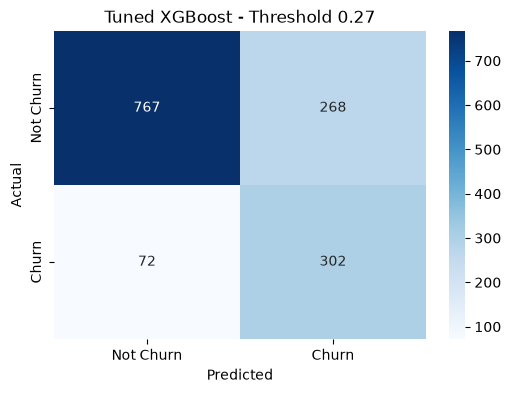

In [175]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    Conf_Matrix_xgb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Churn", "Churn"],
    yticklabels=["Not Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Tuned XGBoost - Threshold 0.27")
plt.show()

In [176]:
feature_names = best_xgb.named_steps["preprocessor"].get_feature_names_out()

print(len(feature_names))
print(feature_names[:20])

51
['numbers__tenure' 'numbers__MonthlyCharges' 'numbers__TotalCharges'
 'cat__gender_Female' 'cat__gender_Male' 'cat__SeniorCitizen_0'
 'cat__SeniorCitizen_1' 'cat__Partner_No' 'cat__Partner_Yes'
 'cat__Dependents_No' 'cat__Dependents_Yes' 'cat__PhoneService_No'
 'cat__PhoneService_Yes' 'cat__MultipleLines_No'
 'cat__MultipleLines_No phone service' 'cat__MultipleLines_Yes'
 'cat__InternetService_DSL' 'cat__InternetService_Fiber optic'
 'cat__InternetService_No' 'cat__OnlineSecurity_No']


In [177]:

importance = best_xgb.named_steps["XGB_Classifier"].feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_df.head(20)

,Feature,Importance
37,cat__Contract_Month-to-month,0.446388
17,cat__InternetService_Fiber optic,0.133739
19,cat__OnlineSecurity_No,0.037894
28,cat__TechSupport_No,0.037668
39,cat__Contract_Two year,0.023459
0,numbers__tenure,0.023302
36,cat__StreamingMovies_Yes,0.022940
16,cat__InternetService_DSL,0.018709
44,cat__PaymentMethod_Electronic check,0.017178
38,cat__Contract_One year,0.015957


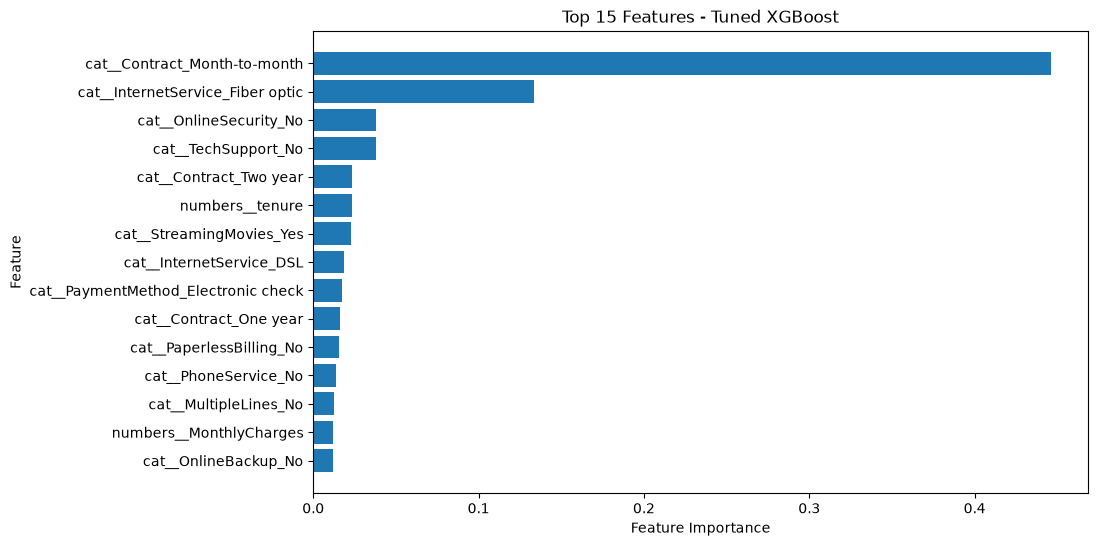

In [178]:
top_features = feature_importance_df.head(15).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features - Tuned XGBoost")
plt.show()

In [179]:
import shap

In [180]:
X_test_transformed = best_xgb.named_steps["preprocessor"].transform(X_test)

print(X_test_transformed.shape)

(1409, 51)


In [181]:
feature_names = best_xgb.named_steps["preprocessor"].get_feature_names_out()

print(len(feature_names))

51


In [182]:
xgb_classifier = best_xgb.named_steps["XGB_Classifier"]

In [183]:
explainer = shap.TreeExplainer(xgb_classifier)

shap_values = explainer.shap_values(X_test_transformed)

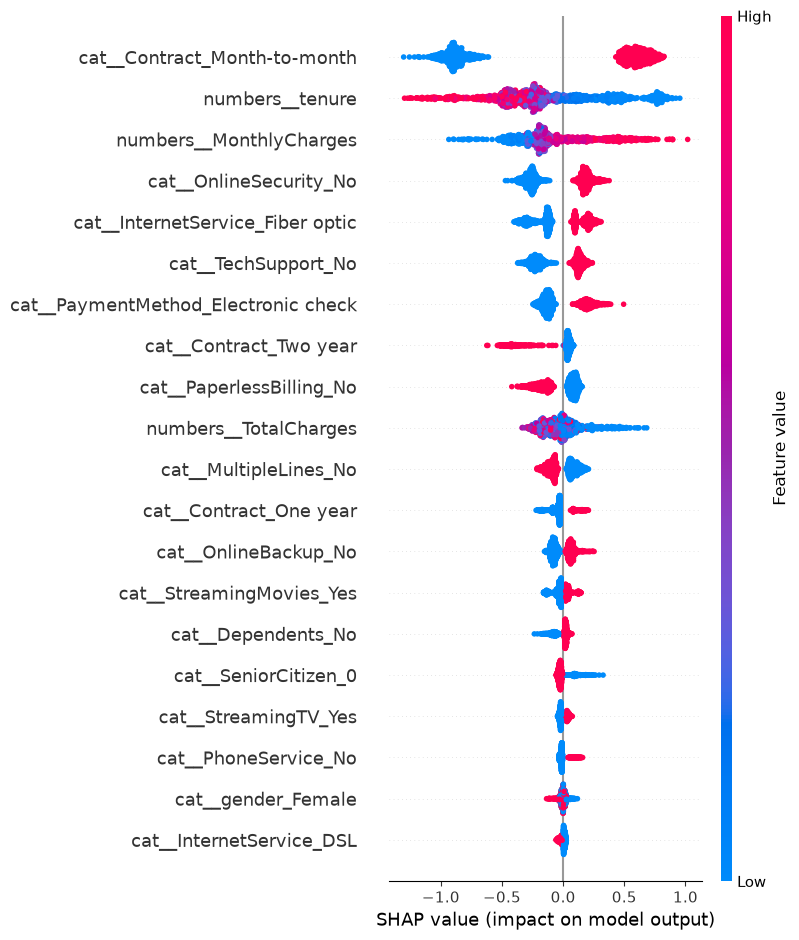

In [184]:
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)

In [ ]:
X_test_transformed = best_xgb.named_steps["preprocessor"].transform(X_test)

print(X_test_transformed.shape)

feature_names = best_xgb.named_steps["preprocessor"].get_feature_names_out()

print(len(feature_names))

xgb_classifier = best_xgb.named_steps["XGB_Classifier"]

explainer = shap.TreeExplainer(xgb_classifier)

shap_values = explainer.shap_values(X_test_transformed)


shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=feature_names
)



(1409, 51)


In [186]:


# Mean absolute SHAP value for each encoded feature
mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_encoded_df = pd.DataFrame({
    "Feature": feature_names,
    "Mean_Abs_SHAP": mean_abs_shap
})

# Group encoded features back to original features
grouped_shap = {}

for feature in numerical_features:
    mask = shap_encoded_df["Feature"].str.contains(
        f"__{feature}$",
        regex=True
    )
    grouped_shap[feature] = shap_encoded_df.loc[
        mask, "Mean_Abs_SHAP"
    ].sum()

for feature in categorical_features:
    mask = shap_encoded_df["Feature"].str.startswith(
        f"cat__{feature}_"
    )
    grouped_shap[feature] = shap_encoded_df.loc[
        mask, "Mean_Abs_SHAP"
    ].sum()

grouped_shap_df = pd.DataFrame(
    list(grouped_shap.items()),
    columns=["Feature", "Mean_Abs_SHAP"]
).sort_values(
    "Mean_Abs_SHAP",
    ascending=False
)

grouped_shap_df

,Feature,Mean_Abs_SHAP
16,Contract,0.938302
0,tenure,0.395311
1,MonthlyCharges,0.272106
10,OnlineSecurity,0.233878
9,InternetService,0.204405
13,TechSupport,0.181072
18,PaymentMethod,0.179962
17,PaperlessBilling,0.122880
2,TotalCharges,0.117200
8,MultipleLines,0.107892


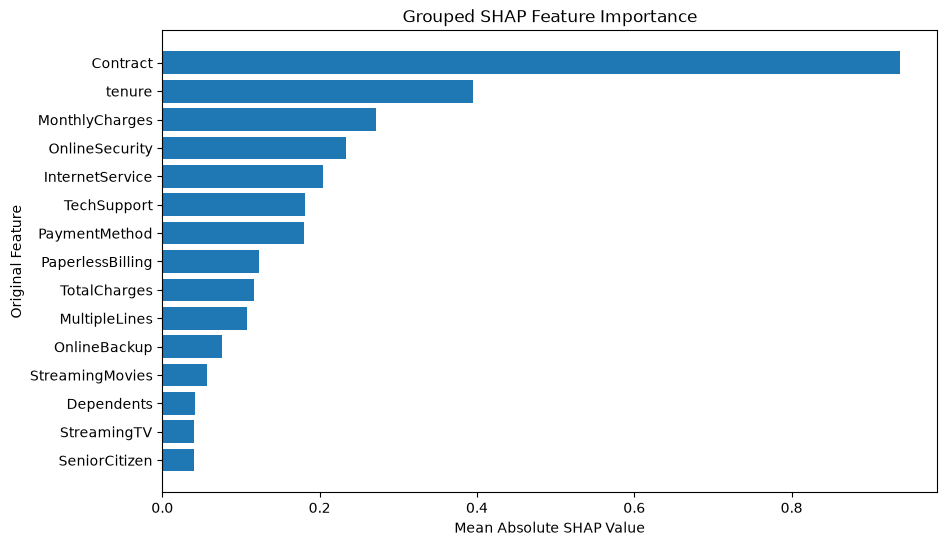

In [187]:
top_grouped = grouped_shap_df.head(15).sort_values(
    "Mean_Abs_SHAP"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_grouped["Feature"],
    top_grouped["Mean_Abs_SHAP"]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Original Feature")
plt.title("Grouped SHAP Feature Importance")
plt.show()

In [188]:
customer_risk = pd.DataFrame({
    "index": X_test.index,
    "churn_probability": Y_prob_xgb_tuned
})

customer_risk = customer_risk.sort_values(
    "churn_probability",
    ascending=False
)

customer_risk.head(10)

,index,churn_probability
1090,3380,0.919044
618,6623,0.918939
1109,4585,0.909916
1221,6866,0.909453
1259,2464,0.905936
1175,2631,0.885125
733,3536,0.881192
171,2194,0.880882
872,383,0.875611
813,5706,0.869203


In [191]:
customer_index = customer_risk.iloc[0]["index"]

In [192]:
customer = X_test.loc[[customer_index]]

print(customer.T)

                              3380
gender                        Male
SeniorCitizen                    1
Partner                        Yes
Dependents                      No
tenure                           1
PhoneService                   Yes
MultipleLines                  Yes
InternetService        Fiber optic
OnlineSecurity                  No
OnlineBackup                    No
DeviceProtection                No
TechSupport                     No
StreamingTV                    Yes
StreamingMovies                Yes
Contract            Month-to-month
PaperlessBilling               Yes
PaymentMethod     Electronic check
MonthlyCharges                95.1
TotalCharges                  95.1
tenure_group           0-12 months


In [193]:
shap_values

array([[-1.10918224e+00,  3.58933210e-01, -2.11108886e-02, ...,
         7.96177264e-05,  0.00000000e+00,  0.00000000e+00],
       [ 3.54779392e-01,  6.39130533e-01,  1.25246838e-01, ...,
         1.44171878e-04,  0.00000000e+00,  0.00000000e+00],
       [-1.77114561e-01, -5.14402092e-02,  2.79873759e-02, ...,
        -3.25628696e-03,  0.00000000e+00,  0.00000000e+00],
       ...,
       [ 2.76549906e-01, -3.63365591e-01,  4.34704386e-02, ...,
         5.69541939e-04,  0.00000000e+00,  0.00000000e+00],
       [-2.18087792e-01, -2.97154754e-01,  1.22853905e-01, ...,
         6.97128358e-04,  0.00000000e+00,  0.00000000e+00],
       [-9.69925106e-01, -2.00008154e-01,  7.79430196e-03, ...,
         8.75544938e-05,  0.00000000e+00,  0.00000000e+00]],
      shape=(1409, 51), dtype=float32)

In [196]:
customer_position = X_test.index.get_loc(customer_index)
customer_shap = shap_values[customer_position]



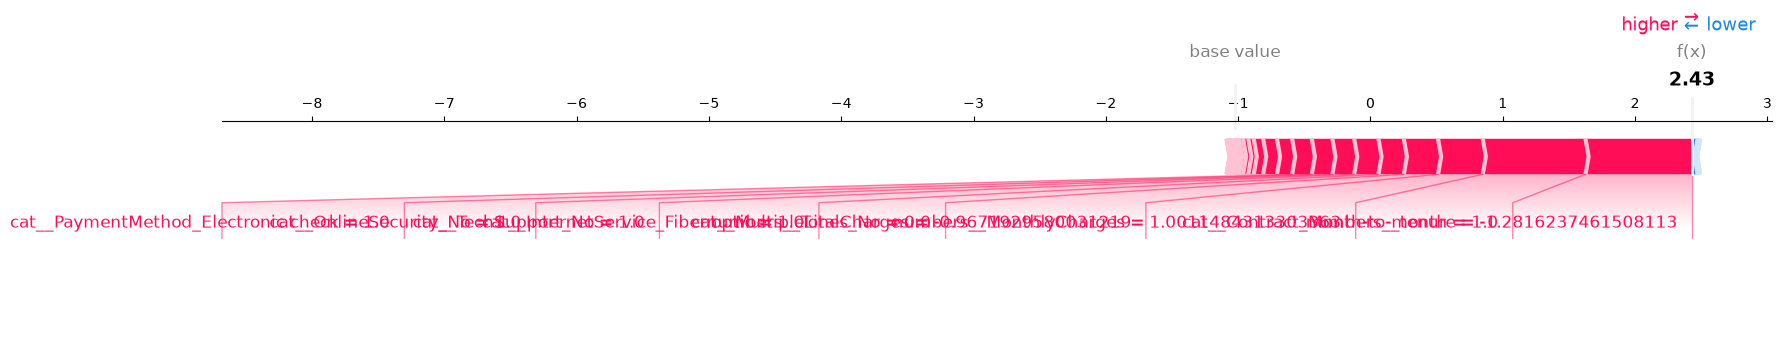

In [202]:
shap.force_plot(
    explainer.expected_value,
    customer_shap,
    X_test_transformed[customer_position],
    feature_names=feature_names,
    matplotlib=True
    
)

plt.show()

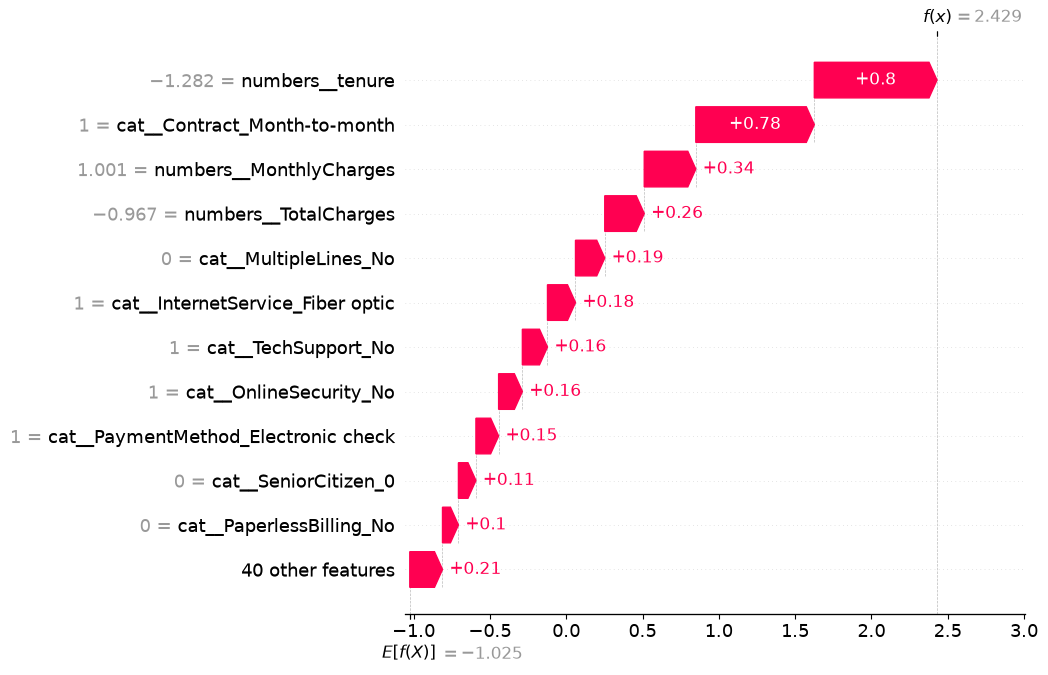

In [201]:
customer_explanation = shap.Explanation(
    values=customer_shap,
    base_values=explainer.expected_value,
    data=X_test_transformed[customer_position],
    feature_names=feature_names
)

shap.plots.waterfall(
    customer_explanation,
    max_display=12
)

In [203]:
churn_probability = Y_prob_xgb_tuned[customer_position]

print(f"Churn probability: {churn_probability:.2%}")
print(f"Classification threshold: 27%")
print(f"Predicted class: {'Churn' if churn_probability >= 0.27 else 'Not Churn'}")

Churn probability: 91.90%
Classification threshold: 27%
Predicted class: Churn


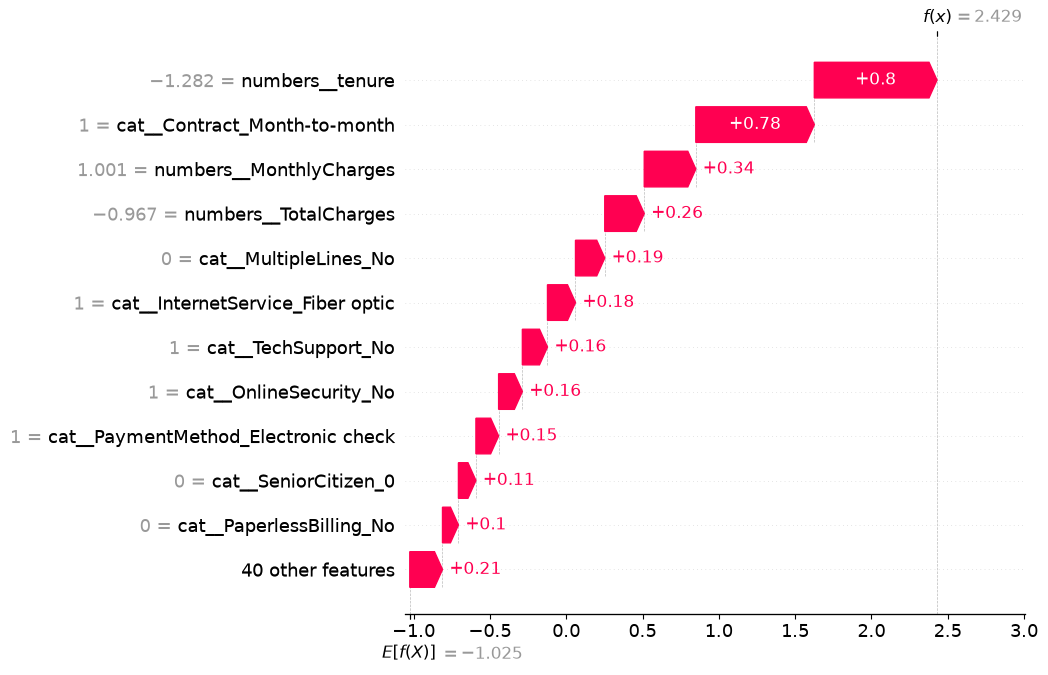

In [204]:
customer_explanation = shap.Explanation(
    values=customer_shap,
    base_values=explainer.expected_value,
    data=X_test_transformed[customer_position],
    feature_names=feature_names
)

shap.plots.waterfall(
    customer_explanation,
    max_display=12
)

In [210]:
cost_FN = 1000
cost_FP = 100

thresholds = np.arange(0.10, 0.61, 0.01)

results = []

for threshold in thresholds:

    y_pred = (Y_prob_xgb_tuned >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        Y_test,
        y_pred
    ).ravel()

    total_cost = (
        fp * cost_FP +
        fn * cost_FN
    )

    results.append({
        "Threshold": threshold,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
        "Total_Cost": total_cost
    })

cost_df = pd.DataFrame(results)

cost_df.sort_values(
    "Total_Cost"
).head(10)

,Threshold,TN,FP,FN,TP,Total_Cost
3,0.13,581,454,25,349,70400
0,0.10,514,521,19,355,71100
4,0.14,600,435,28,346,71500
2,0.12,559,476,24,350,71600
1,0.11,534,501,22,352,72100
6,0.16,639,396,38,336,77600
5,0.15,614,421,36,338,78100
7,0.17,655,380,46,328,84000
8,0.18,667,368,51,323,87800
9,0.19,682,353,53,321,88300


In [213]:
best_cost_row = cost_df.loc[
    cost_df["Total_Cost"].idxmin()
]

print(best_cost_row)

Threshold         0.13
TN              581.00
FP              454.00
FN               25.00
TP              349.00
Total_Cost    70400.00
Name: 3, dtype: float64


In [214]:
import joblib

final_model = {
    "model": best_xgb,
    "threshold": 0.27
}

joblib.dump(
    final_model,
    "../models/churn_xgb_model.joblib"
)

print("Model saved successfully!")

Model saved successfully!


In [215]:
import os

print(
    os.path.exists("../models/churn_xgb_model.joblib")
)

True


In [216]:
loaded_model = joblib.load(
    "../models/churn_xgb_model.joblib"
)

print(loaded_model.keys())

dict_keys(['model', 'threshold'])


In [217]:
loaded_xgb = loaded_model["model"]
loaded_threshold = loaded_model["threshold"]

print("Threshold:", loaded_threshold)

Threshold: 0.27


In [218]:
loaded_probabilities = loaded_xgb.predict_proba(
    X_test
)[:, 1]

loaded_predictions = (
    loaded_probabilities >= loaded_threshold
).astype(int)

In [220]:
print(
    "Predictions identical:",
    np.array_equal(
        Y_pred_xbg_Final,
        loaded_predictions
    )
)

Predictions identical: True


In [222]:
def predict_churn(customer_data, model_package):
    
    model = model_package["model"]
    threshold = model_package["threshold"]

    probability = model.predict_proba(
        customer_data
    )[:, 1][0]

    prediction = int(probability >= threshold)

    return {
        "churn_probability": probability,
        "prediction": prediction,
        "risk": "High" if prediction == 1 else "Low"
    }
sample_customer = X_test.iloc[[0]]

result = predict_churn(
    sample_customer,
    loaded_model
)

print(result)

{'churn_probability': np.float32(0.016445145), 'prediction': 0, 'risk': 'Low'}


In [224]:
print(os.path.exists("../models/churn_xgb_model.joblib"))
print(loaded_model.keys())
print(np.array_equal(Y_pred_xbg_Final, loaded_predictions))

True
dict_keys(['model', 'threshold'])
True


In [225]:
{
  "churn_probability": 0.76,
  "prediction": "Churn",
  "risk": "High"
}

{'churn_probability': 0.76, 'prediction': 'Churn', 'risk': 'High'}

In [226]:
print(best_xgb.named_steps["preprocessor"].feature_names_in_)

['gender' 'SeniorCitizen' 'Partner' 'Dependents' 'tenure' 'PhoneService'
 'MultipleLines' 'InternetService' 'OnlineSecurity' 'OnlineBackup'
 'DeviceProtection' 'TechSupport' 'StreamingTV' 'StreamingMovies'
 'Contract' 'PaperlessBilling' 'PaymentMethod' 'MonthlyCharges'
 'TotalCharges' 'tenure_group']


In [227]:
print(X_train.columns.tolist())
print(categorical_features)

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'tenure_group']
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group']


In [228]:
print(X_train[["tenure", "tenure_group"]].head(20))

      tenure  tenure_group
3738      35  25-48 months
3151      15  13-24 months
4860      13  13-24 months
3867      26  25-48 months
3810       1   0-12 months
2666      66  49-72 months
2645       1   0-12 months
189       40  25-48 months
5767      65  49-72 months
2257      60  49-72 months
2641       5   0-12 months
6950       5   0-12 months
3938       2   0-12 months
2764      30  25-48 months
3113      36  25-48 months
2986      55  49-72 months
5427      31  25-48 months
328       28  25-48 months
11        16  13-24 months
4559       6   0-12 months


In [229]:
print("Threshold:", loaded_threshold)

Threshold: 0.27


In [232]:
import joblib
from pathlib import Path

# Create models directory
models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)

# Save the complete trained pipeline
model_path = models_dir / "churn_xgb_model.joblib"

joblib.dump(best_xgb, model_path)

print(f"Model saved to: {model_path}")

Model saved to: ..\models\churn_xgb_model.joblib


In [233]:
print(list(models_dir.iterdir()))

[WindowsPath('../models/churn_xgb_model.joblib'), WindowsPath('../models/threshold.txt')]


In [237]:
loaded_model = joblib.load(
    "../models/churn_xgb_model.joblib"
)

loaded_threshold = float(
    Path("../models/threshold.txt").read_text()
)

print("Model loaded successfully")
print("Threshold:", loaded_threshold)

Model loaded successfully
Threshold: 0.27


In [238]:
test_probability = loaded_model.predict_proba(X_test)[:, 1]

test_prediction = (
    test_probability >= loaded_threshold
).astype(int)

print(test_probability[:5])
print(test_prediction[:5])

[0.01644515 0.81807745 0.07026532 0.3050077  0.01279636]
[0 1 0 1 0]


In [239]:
joblib.dump(best_xgb, "../models/churn_xgb_model.joblib")

['../models/churn_xgb_model.joblib']

In [240]:
loaded_model = joblib.load(
    "../models/churn_xgb_model.joblib"
)

print(loaded_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numbers', StandardScaler(),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['gender', 'SeniorCitizen',
                                                   'Partner', 'Dependents',
                                                   'PhoneService',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                           